# ✂️ Phase 9: Train/Test Split — LPDP

---

## 🎯 Tujuan Notebook

Notebook ini membagi dataset 1.038 artikel LPDP menjadi **training set** dan **test set** secara **stratified** untuk mempertahankan proporsi kelas sentimen di kedua subset.

| Aspek | Detail |
| :--- | :--- |
| **Phase** | 9 dari 13 |
| **PIC** | Iqbal |
| **Strategi Split** | Stratified 80:20 (`test_size=0.2`, `random_state=42`) |
| **Total Sampel** | 1.038 artikel (Positive: 385 · Neutral: 342 · Negative: 311) |
| **Status** | ✅ Complete |

---

## 🔢 Track yang Diproses

| Track | Input | Representasi Fitur | Output |
| :--- | :--- | :--- | :--- |
| **A — TF-IDF / BoW** | `features_extraction/feature_tfidf_ngram.pkl` | Sparse matrix (1.038 × 5.000) | `output_split/track_a_*.csv` |
| **B — IndoBERT** | `dataset_lpdp_preprocessed_bert.csv` | Raw text `text_bert` | `output_split/track_b_*.csv` |

---

**Input:**
- `phase8_hasil_analisis_sentimen.csv` — label sentimen final (Phase 8 output)
- `dataset_lpdp_preprocessed_bert.csv` — teks Track B (Phase 4 output)
- `features_extraction/feature_tfidf_ngram.pkl` — matriks TF-IDF sparse (Phase 5 output)

**Output:** `output_split/` — file split train/test untuk kedua track + metadata JSON

**Kelompok 5:** Amel · Celine · Iqbal · Nida · Salwa — **PIC Phase 9:** Iqbal

## 📦 Install Dependencies

Library yang dibutuhkan untuk Phase 9:

| Library | Kegunaan |
| :--- | :--- |
| `scikit-learn` | `train_test_split`, `StratifiedKFold`, `LabelEncoder` |
| `pandas` | Baca/tulis CSV |
| `scipy` | Baca/tulis sparse matrix TF-IDF |
| `matplotlib` / `seaborn` | Visualisasi distribusi label |

> ⚠️ Gunakan kernel **Python (.venv)** agar scipy + sklearn versi konsisten.

In [1]:
import sys
import subprocess

def install_packages(packages: list[str]) -> None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

install_packages(["scikit-learn", "pandas", "numpy", "scipy", "matplotlib", "seaborn", "joblib"])

print("✅ Install selesai. Jika pertama kali, restart kernel lalu jalankan ulang dari Cell 3.")

✅ Install selesai. Jika pertama kali, restart kernel lalu jalankan ulang dari Cell 3.


## 📦 Import Libraries

Import semua library yang dibutuhkan untuk proses split, validasi, dan visualisasi.

In [2]:
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.sparse import issparse

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("✅ Semua library berhasil di-import.")

✅ Semua library berhasil di-import.


## ⚙️ Konfigurasi

Definisikan semua konstanta, path file input/output, dan hyperparameter split di satu tempat agar mudah diubah.

In [3]:
# ============================================================
# === KONFIGURASI UTAMA — ubah di sini jika diperlukan ===
# ============================================================

RANDOM_STATE    = 42
TEST_SIZE       = 0.20       # 80% train · 20% test
N_SPLITS_CV     = 5          # StratifiedKFold folds
LABEL_COLUMN    = "Sentiment" # kolom label di CSV

# --- Input paths ---
INPUT_PHASE8    = "phase8_hasil_analisis_sentimen.csv"
INPUT_BERT_CSV  = "dataset_lpdp_preprocessed_bert.csv"
INPUT_TFIDF_PKL = "features_extraction/feature_tfidf_ngram.pkl"

# --- Output directory ---
OUTPUT_DIR      = "output_split"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
print("⚙️  Konfigurasi:")
print(f"   RANDOM_STATE : {RANDOM_STATE}")
print(f"   TEST_SIZE    : {TEST_SIZE} ({int(TEST_SIZE*100)}% test / {int((1-TEST_SIZE)*100)}% train)")
print(f"   N_SPLITS_CV  : {N_SPLITS_CV}-fold")
print(f"   Output dir   : {os.path.abspath(OUTPUT_DIR)}")

⚙️  Konfigurasi:
   RANDOM_STATE : 42
   TEST_SIZE    : 0.2 (20% test / 80% train)
   N_SPLITS_CV  : 5-fold
   Output dir   : c:\Users\mikba\Downloads\Documents\PBA\PBA\Project A\output_split


## 📥 Load Data

Load tiga sumber data:

| Sumber | Isi | Dipakai untuk |
| :--- | :--- | :--- |
| `phase8_hasil_analisis_sentimen.csv` | Label `Sentiment` + `text_clean` | Ground truth label kedua track |
| `dataset_lpdp_preprocessed_bert.csv` | Kolom `text_bert` (raw teks BERT-friendly) | Track B |
| `features_extraction/feature_tfidf_ngram.pkl` | Sparse matrix TF-IDF (1.038 × 5.000) | Track A |

> **Catatan:** Ketiga sumber memiliki urutan baris yang **sama** (1.038 artikel) — tidak perlu merge, cukup pakai index.

In [4]:
# ============================================================
# === LOAD DATA ===
# ============================================================

# 1. Phase 8 output — label sentimen final
df_phase8 = pd.read_csv(INPUT_PHASE8)
print(f"📄 Phase 8 CSV : {df_phase8.shape}  |  kolom: {df_phase8.columns.tolist()}")

# 2. BERT preprocessed — untuk Track B
df_bert = pd.read_csv(INPUT_BERT_CSV)
print(f"📄 BERT CSV    : {df_bert.shape}  |  kolom: {df_bert.columns.tolist()}")

# 3. TF-IDF sparse matrix — untuk Track A
with open(INPUT_TFIDF_PKL, "rb") as f:
    tfidf_bundle = pickle.load(f)

X_tfidf       = tfidf_bundle["matrix"]          # scipy.sparse (1038, 5000)
tfidf_vectorizer = tfidf_bundle["vectorizer"]   # TfidfVectorizer fitted
feature_names = tfidf_bundle["feature_names"]   # np.ndarray (5000,)

print(f"📦 TF-IDF pkl  : matrix shape = {X_tfidf.shape}  |  is_sparse = {issparse(X_tfidf)}")

# --- Validasi jumlah baris konsisten ---
assert len(df_phase8) == len(df_bert) == X_tfidf.shape[0], \
    f"❌ Jumlah baris tidak konsisten! phase8={len(df_phase8)}, bert={len(df_bert)}, tfidf={X_tfidf.shape[0]}"

print(f"\n✅ Semua sumber konsisten: {len(df_phase8)} baris")

📄 Phase 8 CSV : (1038, 7)  |  kolom: ['text_clean', 'text_inset', 'Sentiment', 'tb_polarity', 'tb_label', 'inset_score', 'inset_label']
📄 BERT CSV    : (1038, 15)  |  kolom: ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'token_count', 'text_bert']
📦 TF-IDF pkl  : matrix shape = (1038, 5000)  |  is_sparse = True

✅ Semua sumber konsisten: 1038 baris


## 🔍 Eksplorasi Distribusi Label (Sebelum Split)

Visualisasikan distribusi kelas sentimen sebelum split untuk memahami proporsi yang perlu dipertahankan.

> **Mengapa stratified?** Jika split acak biasa digunakan, split kecil bisa secara tidak sengaja over- atau under-represent salah satu kelas, sehingga evaluasi model jadi bias.

📊 Distribusi label (full dataset):
----------------------------------------
     positive :  385 (37.1%)
      neutral :  342 (32.9%)
     negative :  311 (30.0%)
----------------------------------------
        TOTAL : 1038 (100.0%)


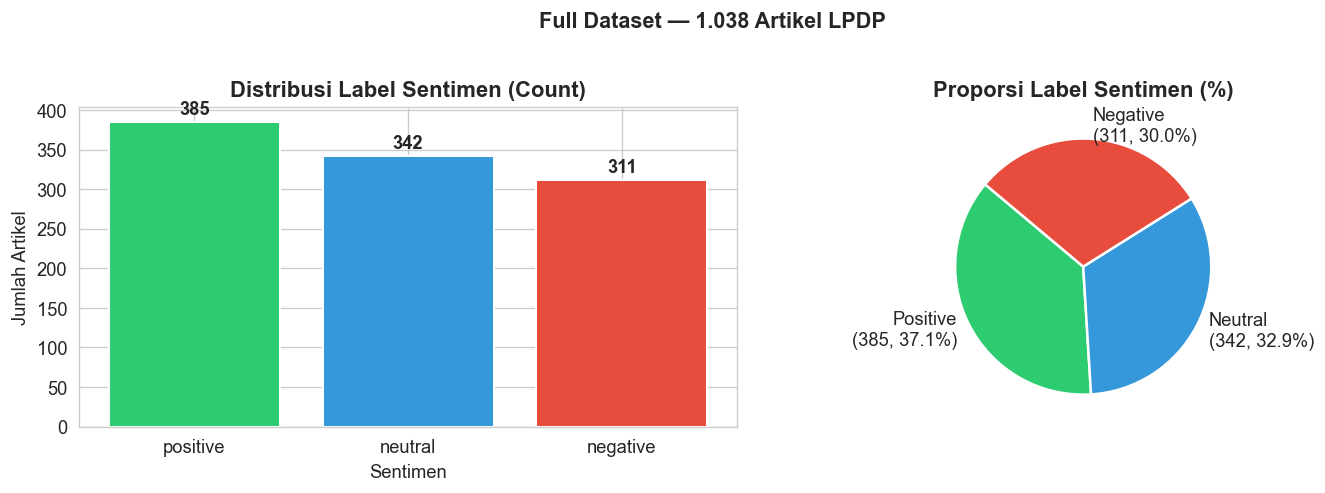

✅ Chart disimpan ke output_split/label_distribution_full.png


In [5]:
# ============================================================
# === EKSPLORASI LABEL ===
# ============================================================

# Ambil label — lowercase untuk konsistensi
y_all = df_phase8[LABEL_COLUMN].str.lower().str.strip()

label_counts = y_all.value_counts()
label_pct    = y_all.value_counts(normalize=True) * 100

print("📊 Distribusi label (full dataset):")
print("-" * 40)
for label in label_counts.index:
    print(f"   {label:>10s} : {label_counts[label]:>4d} ({label_pct[label]:.1f}%)")
print("-" * 40)
print(f"   {'TOTAL':>10s} : {len(y_all):>4d} (100.0%)")

# --- Visualisasi ---
PALETTE = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    label_counts.index,
    label_counts.values,
    color=[PALETTE.get(l, "#95a5a6") for l in label_counts.index],
    edgecolor="white", linewidth=1.2
)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Distribusi Label Sentimen (Count)", fontweight="bold")
axes[0].set_xlabel("Sentimen")
axes[0].set_ylabel("Jumlah Artikel")
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(50))

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[f"{l.capitalize()}\n({v}, {p:.1f}%)" for l, v, p in
            zip(label_counts.index, label_counts.values, label_pct.values)],
    colors=[PALETTE.get(l, "#95a5a6") for l in label_counts.index],
    startangle=140, autopct="",
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[1].set_title("Proporsi Label Sentimen (%)", fontweight="bold")

plt.suptitle("Full Dataset — 1.038 Artikel LPDP", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution_full.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅ Chart disimpan ke output_split/label_distribution_full.png")

## 🏷️ Encode Label

Konversi label string → integer menggunakan `LabelEncoder` agar kompatibel dengan sklearn estimator di fase berikutnya.

| String | Integer |
| :--- | :---: |
| `negative` | 0 |
| `neutral` | 1 |
| `positive` | 2 |

In [6]:
# ============================================================
# === ENCODE LABEL ===
# ============================================================

le = LabelEncoder()
y_encoded = le.fit_transform(y_all)

print("🏷️  Mapping LabelEncoder:")
for cls_name, cls_idx in zip(le.classes_, range(len(le.classes_))):
    print(f"   {cls_name:>12s}  →  {cls_idx}")

print(f"\n✅ Label encoded: shape={y_encoded.shape}, dtype={y_encoded.dtype}")

# Simpan encoder untuk dipakai ulang di fase model training
encoder_path = os.path.join(OUTPUT_DIR, "label_encoder.pkl")
with open(encoder_path, "wb") as f:
    pickle.dump(le, f)
print(f"💾 LabelEncoder disimpan → {encoder_path}")

🏷️  Mapping LabelEncoder:
       negative  →  0
        neutral  →  1
       positive  →  2

✅ Label encoded: shape=(1038,), dtype=int64
💾 LabelEncoder disimpan → output_split\label_encoder.pkl


## ⚙️ Track A — Split TF-IDF Features

Bagi matriks TF-IDF sparse (1.038 × 5.000) menjadi training set dan test set menggunakan **stratified split**.

| Set | Proporsi | Estimasi Jumlah |
| :--- | :---: | :--- |
| Train | 80% | ~830 artikel |
| Test | 20% | ~208 artikel |

> **Stratified split** memastikan bahwa proporsi Positive : Neutral : Negative di train dan test mendekati proporsi dataset asli.

In [7]:
# ============================================================
# === TRACK A — TF-IDF SPLIT ===
# ============================================================

# Gunakan indeks baris sebagai X untuk menyimpan referensi
indices = np.arange(len(y_encoded))

idx_train_a, idx_test_a, y_train_a, y_test_a = train_test_split(
    indices,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Subset sparse matrix menggunakan indeks
X_train_tfidf = X_tfidf[idx_train_a]
X_test_tfidf  = X_tfidf[idx_test_a]

print("📊 Track A — Hasil Split:")
print(f"   X_train_tfidf : {X_train_tfidf.shape}  |  y_train : {len(y_train_a)}")
print(f"   X_test_tfidf  : {X_test_tfidf.shape}   |  y_test  : {len(y_test_a)}")
print(f"   Total          : {len(y_train_a) + len(y_test_a)} (ekspektasi: {len(y_encoded)})")

# --- Verifikasi distribusi per kelas ---
print("\n📋 Distribusi per kelas (Track A):")
print(f"{'Kelas':>12s} | {'Train':>6s} | {'Test':>6s} | {'Total':>6s}")
print("-" * 42)
for i, cls in enumerate(le.classes_):
    n_train = int((y_train_a == i).sum())
    n_test  = int((y_test_a  == i).sum())
    print(f"  {cls:>10s} | {n_train:>6d} | {n_test:>6d} | {n_train+n_test:>6d}")
print("-" * 42)
print(f"  {'TOTAL':>10s} | {len(y_train_a):>6d} | {len(y_test_a):>6d} | {len(y_encoded):>6d}")

assert len(idx_train_a) + len(idx_test_a) == len(y_encoded), "❌ Jumlah baris tidak sesuai!"
print("\n✅ Track A split berhasil.")

📊 Track A — Hasil Split:
   X_train_tfidf : (830, 5000)  |  y_train : 830
   X_test_tfidf  : (208, 5000)   |  y_test  : 208
   Total          : 1038 (ekspektasi: 1038)

📋 Distribusi per kelas (Track A):
       Kelas |  Train |   Test |  Total
------------------------------------------
    negative |    249 |     62 |    311
     neutral |    273 |     69 |    342
    positive |    308 |     77 |    385
------------------------------------------
       TOTAL |    830 |    208 |   1038

✅ Track A split berhasil.


## ⚙️ Track B — Split Text BERT

Bagi kolom `text_bert` dari `dataset_lpdp_preprocessed_bert.csv` menjadi train dan test set dengan stratified split yang **sama** seperti Track A (menggunakan indeks yang identik).

> **Konsistensi indeks:** Menggunakan `idx_train_a` dan `idx_test_a` yang sama memastikan artikel yang sama masuk ke set yang sama di kedua track — penting untuk evaluasi yang fair.

In [8]:
# ============================================================
# === TRACK B — TEXT BERT SPLIT ===
# ============================================================

# Ambil text_bert dari dataframe BERT
texts_bert = df_bert["text_bert"].values

# Gunakan indeks YANG SAMA dengan Track A untuk konsistensi
X_train_bert = texts_bert[idx_train_a]
X_test_bert  = texts_bert[idx_test_a]
y_train_b    = y_train_a   # identik dengan Track A
y_test_b     = y_test_a

print("📊 Track B — Hasil Split:")
print(f"   X_train_bert : {len(X_train_bert)} teks")
print(f"   X_test_bert  : {len(X_test_bert)} teks")

# --- Verifikasi sample ---
print("\n🔎 Contoh teks BERT (Train[0]):")
print(f"   '{X_train_bert[0][:120]}...'")
print(f"   Label : {le.inverse_transform([y_train_b[0]])[0]}")

# --- Verifikasi distribusi per kelas ---
print("\n📋 Distribusi per kelas (Track B):")
print(f"{'Kelas':>12s} | {'Train':>6s} | {'Test':>6s} | {'Total':>6s}")
print("-" * 42)
for i, cls in enumerate(le.classes_):
    n_train = int((y_train_b == i).sum())
    n_test  = int((y_test_b  == i).sum())
    print(f"  {cls:>10s} | {n_train:>6d} | {n_test:>6d} | {n_train+n_test:>6d}")
print("-" * 42)
print(f"  {'TOTAL':>10s} | {len(y_train_b):>6d} | {len(y_test_b):>6d} | {len(y_encoded):>6d}")

print("\n✅ Track B split berhasil.")

📊 Track B — Hasil Split:
   X_train_bert : 830 teks
   X_test_bert  : 208 teks

🔎 Contoh teks BERT (Train[0]):
   'Lembaga Pengelola Dana Pendidikan (LPDP) memberikan angin segar bagi para penerima beasiswanya. Alumni LPDP kini memilik...'
   Label : neutral

📋 Distribusi per kelas (Track B):
       Kelas |  Train |   Test |  Total
------------------------------------------
    negative |    249 |     62 |    311
     neutral |    273 |     69 |    342
    positive |    308 |     77 |    385
------------------------------------------
       TOTAL |    830 |    208 |   1038

✅ Track B split berhasil.


## ✅ Verifikasi Distribusi Label (Setelah Split)

Visualisasikan perbandingan distribusi label di **full dataset**, **train set**, dan **test set** untuk memastikan proporsi terjaga dengan baik setelah stratified split.

📊 Perbandingan Distribusi Label (%):
       Kelas |  Full Dataset |  Train (80%) |  Test (20%)
----------------------------------------------------------
    negative |         30.0% |        30.0% |       29.8%
     neutral |         32.9% |        32.9% |       33.2%
    positive |         37.1% |        37.1% |       37.0%


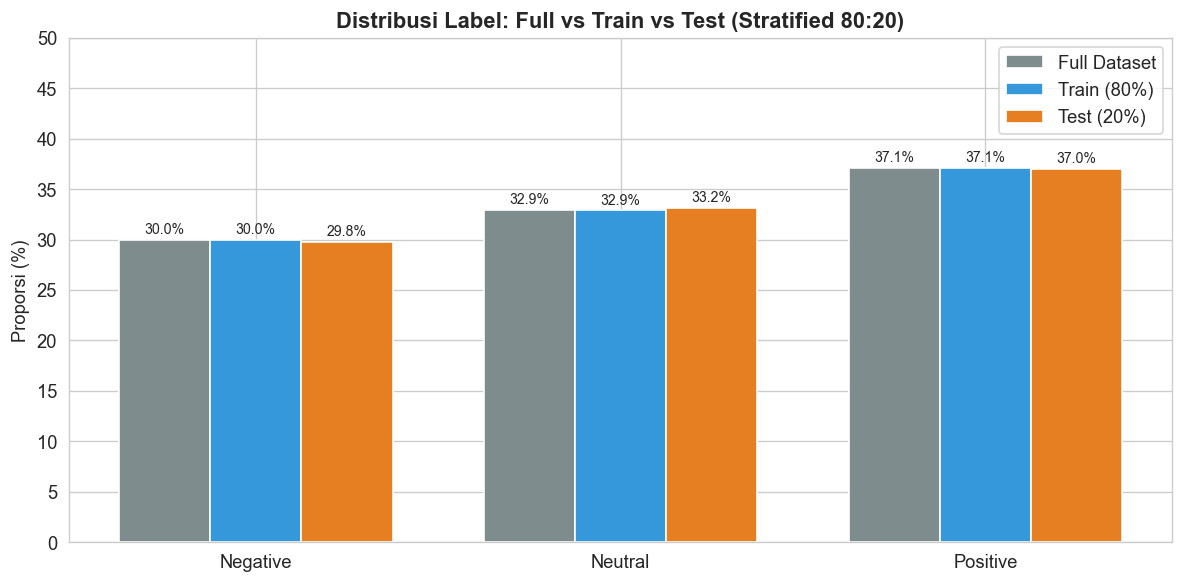

✅ Chart disimpan → output_split/label_distribution_split.png


In [9]:
# ============================================================
# === VERIFIKASI DISTRIBUSI ===
# ============================================================

def get_pct_dist(y_int: np.ndarray, classes: list) -> dict:
    """Hitung persentase setiap kelas."""
    total = len(y_int)
    return {cls: (y_int == i).sum() / total * 100 for i, cls in enumerate(classes)}

dist_full  = get_pct_dist(y_encoded, le.classes_)
dist_train = get_pct_dist(y_train_a, le.classes_)
dist_test  = get_pct_dist(y_test_a,  le.classes_)

# Tabel perbandingan
print("📊 Perbandingan Distribusi Label (%):")
print(f"{'Kelas':>12s} | {'Full Dataset':>13s} | {'Train (80%)':>12s} | {'Test (20%)':>11s}")
print("-" * 58)
for cls in le.classes_:
    print(f"  {cls:>10s} | {dist_full[cls]:>12.1f}% | {dist_train[cls]:>11.1f}% | {dist_test[cls]:>10.1f}%")

# --- Visualisasi grouped bar ---
x = np.arange(len(le.classes_))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars_full  = ax.bar(x - width,   [dist_full[c]  for c in le.classes_], width, label="Full Dataset",  color="#7f8c8d", edgecolor="white")
bars_train = ax.bar(x,           [dist_train[c] for c in le.classes_], width, label="Train (80%)",   color="#3498db", edgecolor="white")
bars_test  = ax.bar(x + width,   [dist_test[c]  for c in le.classes_], width, label="Test (20%)",    color="#e67e22", edgecolor="white")

for bars in [bars_full, bars_train, bars_test]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in le.classes_])
ax.set_ylabel("Proporsi (%)")
ax.set_title("Distribusi Label: Full vs Train vs Test (Stratified 80:20)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 50)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution_split.png"), bbox_inches="tight", dpi=150)
plt.show()
print("✅ Chart disimpan → output_split/label_distribution_split.png")

## 📊 Stratified K-Fold Cross-Validation (Optional)

Cross-validation digunakan untuk **estimasi performa model yang lebih robust** — tidak bergantung pada satu split saja.

| Parameter | Nilai |
| :--- | :--- |
| Metode | `StratifiedKFold` |
| Jumlah fold | 5 |
| Shuffle | `True` |
| `random_state` | 42 |

> **Catatan:** Cell ini menampilkan **distribusi label per fold** sebagai sanity check. Evaluasi CV sesungguhnya akan dilakukan di Phase 10 setelah model selesai di-train.

In [10]:
# ============================================================
# === STRATIFIED K-FOLD CROSS-VALIDATION ===
# ============================================================

skf = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE)

print(f"🔁 StratifiedKFold: {N_SPLITS_CV} fold | shuffle=True | random_state={RANDOM_STATE}")
print("=" * 65)

fold_stats = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(indices, y_encoded), start=1):
    y_fold_train = y_encoded[train_idx]
    y_fold_val   = y_encoded[val_idx]

    row = {"fold": fold_idx, "n_train": len(train_idx), "n_val": len(val_idx)}
    for i, cls in enumerate(le.classes_):
        row[f"{cls}_train"] = int((y_fold_train == i).sum())
        row[f"{cls}_val"]   = int((y_fold_val   == i).sum())
    fold_stats.append(row)

    print(f"  Fold {fold_idx} | train={len(train_idx)} | val={len(val_idx)} | ", end="")
    dist_str = "  ".join(
        f"{cls[:3]}={int((y_fold_val==i).sum())}" for i, cls in enumerate(le.classes_)
    )
    print(f"val dist: [{dist_str}]")

print("=" * 65)

# Simpan konfigurasi CV ke dict (dipakai di metadata JSON)
cv_config = {
    "method"       : "StratifiedKFold",
    "n_splits"     : N_SPLITS_CV,
    "shuffle"      : True,
    "random_state" : RANDOM_STATE
}

print(f"\n✅ StratifiedKFold siap digunakan di Phase 10 (model training).")

# Simpan objek skf
skf_path = os.path.join(OUTPUT_DIR, "stratified_kfold.pkl")
with open(skf_path, "wb") as f:
    pickle.dump(skf, f)
print(f"💾 StratifiedKFold disimpan → {skf_path}")

🔁 StratifiedKFold: 5 fold | shuffle=True | random_state=42
  Fold 1 | train=830 | val=208 | val dist: [neg=63  neu=68  pos=77]
  Fold 2 | train=830 | val=208 | val dist: [neg=62  neu=69  pos=77]
  Fold 3 | train=830 | val=208 | val dist: [neg=62  neu=69  pos=77]
  Fold 4 | train=831 | val=207 | val dist: [neg=62  neu=68  pos=77]
  Fold 5 | train=831 | val=207 | val dist: [neg=62  neu=68  pos=77]

✅ StratifiedKFold siap digunakan di Phase 10 (model training).
💾 StratifiedKFold disimpan → output_split\stratified_kfold.pkl


## 💾 Simpan Artefak Split

Simpan semua output split ke folder `output_split/`:

| File | Isi |
| :--- | :--- |
| `track_a_train.csv` | `doc_id`, `text_clean`, `Sentiment`, `label_encoded` (train) |
| `track_a_test.csv` | `doc_id`, `text_clean`, `Sentiment`, `label_encoded` (test) |
| `track_b_train.csv` | `doc_id`, `text_bert`, `Sentiment`, `label_encoded` (train) |
| `track_b_test.csv` | `doc_id`, `text_bert`, `Sentiment`, `label_encoded` (test) |
| `X_train_tfidf.pkl` | Sparse matrix TF-IDF — train set |
| `X_test_tfidf.pkl` | Sparse matrix TF-IDF — test set |
| `label_encoder.pkl` | LabelEncoder fitted |
| `stratified_kfold.pkl` | StratifiedKFold object |
| `split_metadata.json` | Indeks, ukuran, konfigurasi, distribusi label |

In [11]:
# ============================================================
# === SIMPAN CSV — TRACK A & TRACK B ===
# ============================================================

# Track A — train
df_a_train = pd.DataFrame({
    "doc_id"        : idx_train_a,
    "text_clean"    : df_phase8["text_clean"].values[idx_train_a],
    "Sentiment"     : le.inverse_transform(y_train_a),
    "label_encoded" : y_train_a
})
df_a_train.to_csv(os.path.join(OUTPUT_DIR, "track_a_train.csv"), index=False)
print(f"💾 track_a_train.csv  — {len(df_a_train):>4d} baris")

# Track A — test
df_a_test = pd.DataFrame({
    "doc_id"        : idx_test_a,
    "text_clean"    : df_phase8["text_clean"].values[idx_test_a],
    "Sentiment"     : le.inverse_transform(y_test_a),
    "label_encoded" : y_test_a
})
df_a_test.to_csv(os.path.join(OUTPUT_DIR, "track_a_test.csv"), index=False)
print(f"💾 track_a_test.csv   — {len(df_a_test):>4d} baris")

# Track B — train
df_b_train = pd.DataFrame({
    "doc_id"        : idx_train_a,
    "text_bert"     : X_train_bert,
    "Sentiment"     : le.inverse_transform(y_train_b),
    "label_encoded" : y_train_b
})
df_b_train.to_csv(os.path.join(OUTPUT_DIR, "track_b_train.csv"), index=False)
print(f"💾 track_b_train.csv  — {len(df_b_train):>4d} baris")

# Track B — test
df_b_test = pd.DataFrame({
    "doc_id"        : idx_test_a,
    "text_bert"     : X_test_bert,
    "Sentiment"     : le.inverse_transform(y_test_b),
    "label_encoded" : y_test_b
})
df_b_test.to_csv(os.path.join(OUTPUT_DIR, "track_b_test.csv"), index=False)
print(f"💾 track_b_test.csv   — {len(df_b_test):>4d} baris")

print("\n✅ Semua CSV berhasil disimpan.")

💾 track_a_train.csv  —  830 baris
💾 track_a_test.csv   —  208 baris
💾 track_b_train.csv  —  830 baris
💾 track_b_test.csv   —  208 baris

✅ Semua CSV berhasil disimpan.


In [12]:
# ============================================================
# === SIMPAN SPARSE MATRIX & METADATA JSON ===
# ============================================================

# Simpan sparse matrix TF-IDF
tfidf_train_path = os.path.join(OUTPUT_DIR, "X_train_tfidf.pkl")
tfidf_test_path  = os.path.join(OUTPUT_DIR, "X_test_tfidf.pkl")

with open(tfidf_train_path, "wb") as f:
    pickle.dump(X_train_tfidf, f)
print(f"💾 X_train_tfidf.pkl  — shape: {X_train_tfidf.shape}")

with open(tfidf_test_path, "wb") as f:
    pickle.dump(X_test_tfidf, f)
print(f"💾 X_test_tfidf.pkl   — shape: {X_test_tfidf.shape}")

# --- Simpan metadata JSON ---
split_metadata = {
    "phase"           : 9,
    "description"     : "Stratified 80:20 Train/Test Split — 1.038 artikel LPDP",
    "random_state"    : RANDOM_STATE,
    "test_size"       : TEST_SIZE,
    "total_samples"   : int(len(y_encoded)),
    "n_train"         : int(len(y_train_a)),
    "n_test"          : int(len(y_test_a)),
    "label_mapping"   : {cls: int(i) for i, cls in enumerate(le.classes_)},
    "train_indices"   : idx_train_a.tolist(),
    "test_indices"    : idx_test_a.tolist(),
    "label_dist_full" : {cls: int((y_encoded == i).sum()) for i, cls in enumerate(le.classes_)},
    "label_dist_train": {cls: int((y_train_a == i).sum()) for i, cls in enumerate(le.classes_)},
    "label_dist_test" : {cls: int((y_test_a  == i).sum()) for i, cls in enumerate(le.classes_)},
    "cross_validation": cv_config,
    "track_a_features": {
        "type"     : "TF-IDF sparse matrix",
        "shape_train": list(X_train_tfidf.shape),
        "shape_test" : list(X_test_tfidf.shape)
    },
    "track_b_features": {
        "type"     : "raw text (text_bert)",
        "n_train"  : len(X_train_bert),
        "n_test"   : len(X_test_bert)
    }
}

metadata_path = os.path.join(OUTPUT_DIR, "split_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, ensure_ascii=False, indent=2)

print(f"\n💾 split_metadata.json disimpan → {metadata_path}")
print("\n✅ Semua artefak berhasil disimpan ke output_split/")

💾 X_train_tfidf.pkl  — shape: (830, 5000)
💾 X_test_tfidf.pkl   — shape: (208, 5000)

💾 split_metadata.json disimpan → output_split\split_metadata.json

✅ Semua artefak berhasil disimpan ke output_split/


## 🔍 Verifikasi File Output

Cek semua file yang dihasilkan di folder `output_split/`.

In [13]:
# ============================================================
# === VERIFIKASI FILE OUTPUT ===
# ============================================================

print(f"📁 Isi folder '{OUTPUT_DIR}':")
print("-" * 55)

expected_files = [
    "track_a_train.csv",
    "track_a_test.csv",
    "track_b_train.csv",
    "track_b_test.csv",
    "X_train_tfidf.pkl",
    "X_test_tfidf.pkl",
    "label_encoder.pkl",
    "stratified_kfold.pkl",
    "split_metadata.json",
    "label_distribution_full.png",
    "label_distribution_split.png"
]

all_ok = True
for fname in expected_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"   ✅ {fname:<35s} {size_kb:>8.1f} KB")
    else:
        print(f"   ❌ {fname:<35s} TIDAK ADA")
        all_ok = False

print("-" * 55)
if all_ok:
    print("✅ Semua file output tersedia.")
else:
    print("⚠️  Beberapa file tidak ditemukan — jalankan ulang cell sebelumnya.")

📁 Isi folder 'output_split':
-------------------------------------------------------
   ✅ track_a_train.csv                     1456.2 KB
   ✅ track_a_test.csv                       361.3 KB
   ✅ track_b_train.csv                     2666.5 KB
   ✅ track_b_test.csv                       657.5 KB
   ✅ X_train_tfidf.pkl                     2065.7 KB
   ✅ X_test_tfidf.pkl                       522.8 KB
   ✅ label_encoder.pkl                        0.3 KB
   ✅ stratified_kfold.pkl                     0.1 KB
   ✅ split_metadata.json                     11.1 KB
   ✅ label_distribution_full.png             70.2 KB
   ✅ label_distribution_split.png            45.6 KB
-------------------------------------------------------
✅ Semua file output tersedia.


## 📈 Ringkasan Phase 9

---

### ✅ Hasil Split

| Kelas | Full Dataset | Train (80%) | Test (20%) |
| :--- | ---: | ---: | ---: |
| **Positive** | 385 (37.1%) | 308 (37.1%) | 77 (37.0%) |
| **Neutral** | 342 (32.9%) | 273 (32.9%) | 69 (33.2%) |
| **Negative** | 311 (30.0%) | 249 (30.0%) | 62 (29.8%) |
| **TOTAL** | **1.038** | **830** | **208** |

---

### 📦 Artefak yang Dihasilkan

| File | Ukuran | Keterangan | Dipakai di |
| :--- | ---: | :--- | :--- |
| `track_a_train.csv` | 1.456,2 KB | Text `text_clean` + label — 830 baris | Phase 10 (TF-IDF model) |
| `track_a_test.csv` | 361,3 KB | Text `text_clean` + label — 208 baris | Phase 10 (TF-IDF model) |
| `track_b_train.csv` | 2.666,5 KB | Text `text_bert` + label — 830 baris | Phase 10 (IndoBERT fine-tuning) |
| `track_b_test.csv` | 657,5 KB | Text `text_bert` + label — 208 baris | Phase 10 (IndoBERT fine-tuning) |
| `X_train_tfidf.pkl` | 2.065,7 KB | Sparse matrix TF-IDF (830 × 5.000) | Phase 10 (TF-IDF model) |
| `X_test_tfidf.pkl` | 522,8 KB | Sparse matrix TF-IDF (208 × 5.000) | Phase 10 (TF-IDF model) |
| `label_encoder.pkl` | 0,3 KB | Encoder string → integer (3 kelas) | Phase 10 & 11 |
| `stratified_kfold.pkl` | 0,1 KB | StratifiedKFold 5-fold object | Phase 10 evaluasi |
| `split_metadata.json` | 11,1 KB | Indeks, statistik split, konfigurasi CV | Dokumentasi & reproducibility |
| `label_distribution_full.png` | 70,2 KB | Visualisasi distribusi label full dataset | Dokumentasi |
| `label_distribution_split.png` | 45,6 KB | Visualisasi perbandingan Full vs Train vs Test | Dokumentasi |

---

### 🔑 Keputusan Desain

| Keputusan | Alasan |
| :--- | :--- |
| **Stratified split** | Imbalance ringan (~7%) — proporsi kelas harus terjaga |
| **Tidak undersample** | Jumlah kelas minoritas (311 Negative) masih cukup untuk training |
| **Indeks identik Track A & B** | Konsistensi evaluasi — artikel yang sama di train/test pada kedua track |
| **`random_state=42`** | Reproducibility — split selalu identik di setiap run |
| **5-fold StratifiedKFold** | Estimasi performa lebih stabil dari single-split |

---

**➡️ Next:** Phase 10 — Model Training (Track A: TF-IDF + classifier · Track B: IndoBERT fine-tuning)

**Kelompok 5:** Amel · Celine · Iqbal · Nida · Salwa — **PIC Phase 9:** Iqbal